# Notebook 08b — LightGBM: Weather Effects on Cycling Demand


Fits **LightGBM (Poisson objective)** with **SHAP** for interpretation.

Sections 0–0c and the train/test split are identical to notebook 08.


## 0. Imports & Setup

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lightgbm", "shap"])


0

In [2]:
import pickle
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

COLORS = {
    "commuter" : "#2196F3",
    "mixed"    : "#FFC107",
    "leisure"  : "#F44336",
}

panel = pd.read_parquet(PROCESSED / "analysis_panel.parquet")

site_cls = pd.read_parquet(PROCESSED / "site_classification.parquet")
_want = ["site ID", "site_type"]
if "commute_score" in site_cls.columns:
    _want.append("commute_score")
site_cls = site_cls[_want]
panel = panel.merge(site_cls, on="site ID", how="left")
panel["site_type"] = panel["site_type"].fillna("unclassified")

panel_good = panel[
    (panel["low_coverage"] == False) &
    (panel["aantal"].notna()) &
    (panel["temp_avg"].notna())
].copy()
panel_good["date"] = pd.to_datetime(panel_good["date"])

print(f"Date range : {panel_good['date'].min().date()}  →  {panel_good['date'].max().date()}")
print(f"Total rows : {len(panel_good):,}")
print("\nRows per year:")
print(panel_good['date'].dt.year.value_counts().sort_index().to_string())
print("\nsite_type distribution:")
print(panel_good['site_type'].value_counts().to_string())


/Users/zhuyuxuan/Downloads/Modern Data Analytics/mda-cycling-weather-group6/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Date range : 2023-01-01  →  2025-12-31
Total rows : 144,338

Rows per year:
date
2023    47836
2024    48351
2025    48151

site_type distribution:
site_type
commuter    73141
leisure     43464
mixed       27733


## 0b. Train-only IQR Outlier Audit

Identical to notebook 08 — kept for reproducibility.


In [3]:
# ── per-site IQR stats on train only ──────────────────────────────────
def site_stats(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    return pd.Series({"q1": q1, "q3": q3, "iqr": iqr,
                      "median": x.median(), "upper_fence": q3 + 3 * iqr})

_train_for_iqr = panel_good[panel_good["date"].dt.year.isin([2023, 2024])].copy()
_stats = _train_for_iqr.groupby("site ID")["aantal"].apply(site_stats).unstack()
_train_for_iqr = _train_for_iqr.merge(_stats, on="site ID")

_outliers = _train_for_iqr[
    (_train_for_iqr["aantal"] > _train_for_iqr["upper_fence"]) &
    (_train_for_iqr["iqr"] > 0)
].copy()
_outliers["ratio"] = (_outliers["aantal"] / _outliers["median"]).round(1)

print(f"Total flagged (Q3 + 3×IQR, train 2023-2024): {len(_outliers)}")

_candidates = _outliers[_outliers["ratio"] >= 5][
    ["site ID", "naam", "date", "aantal", "median", "upper_fence", "ratio"]
].copy()
_site_max = _candidates.groupby("site ID")["ratio"].max().rename("site_max")
_candidates = (_candidates
    .merge(_site_max, on="site ID")
    .sort_values(["site_max", "site ID", "ratio"], ascending=[False, True, False])
    .drop(columns="site_max")
)
print()
print("=" * 80)
print("CANDIDATES WITH RATIO >= 5x MEDIAN  (grouped by site, down ratio)")
print("=" * 80)
_current_site = None
for _, row in _candidates.iterrows():
    if row["site ID"] != _current_site:
        _current_site = row["site ID"]
        site_n = _candidates[_candidates["site ID"] == _current_site].shape[0]
        print(f"\n  site {int(row['site ID']):<4}  {row['naam']}  [{site_n} flagged date(s)]")
    print(f"    {str(row['date'])[:10]}  aantal={int(row['aantal']):>6}  "
          f"median={row['median']:>6.1f}  fence={row['upper_fence']:>8.1f}  ratio={row['ratio']:.1f}x")


Total flagged (Q3 + 3×IQR, train 2023-2024): 125

CANDIDATES WITH RATIO >= 5x MEDIAN  (grouped by site, down ratio)

  site 105   St. pieters leeuw teller 2  [1 flagged date(s)]
    2023-03-03  aantal=   807  median=   0.0  fence=   232.0  ratio=infx

  site 85    Asse teller 1  [3 flagged date(s)]
    2024-07-25  aantal=  4823  median=  82.0  fence=   268.0  ratio=58.8x
    2024-07-21  aantal=   904  median=  82.0  fence=   268.0  ratio=11.0x
    2024-07-07  aantal=   660  median=  82.0  fence=   268.0  ratio=8.0x

  site 83    Beersel teller 2  [16 flagged date(s)]
    2024-03-31  aantal=  1796  median=  46.0  fence=   141.0  ratio=39.0x
    2024-03-19  aantal=  1748  median=  46.0  fence=   141.0  ratio=38.0x
    2024-03-30  aantal=  1720  median=  46.0  fence=   141.0  ratio=37.4x
    2024-04-06  aantal=  1534  median=  46.0  fence=   141.0  ratio=33.3x
    2024-03-29  aantal=  1443  median=  46.0  fence=   141.0  ratio=31.4x
    2024-04-01  aantal=  1217  median=  46.0  fence=   1

## 0c. Outlier Blacklist, Event Flags & Train/Test Split

Identical to notebook 08.


In [4]:
# ── outlier blacklist (informed by IQR audit above) ───────────────────
remove_dates = [
    (105, '2023-03-03'),
    (85,  '2024-07-25'),
    (20,  '2024-06-02'),
    (140, '2024-07-13'),
    (129, '2024-08-12'),
    (78,  '2023-07-01'),
    (50,  '2024-09-18'),
    (94,  '2023-08-20'),
    (33,  '2023-01-20'),
    (81,  '2024-08-18'),
    (83,  '2024-03-19'),
    (83,  '2024-03-27'), (83,  '2024-03-28'), (83,  '2024-03-29'),
    (83,  '2024-03-30'), (83,  '2024-03-31'), (83,  '2024-04-01'),
    (83,  '2024-04-02'), (83,  '2024-04-03'), (83,  '2024-04-04'),
    (83,  '2024-04-05'), (83,  '2024-04-06'), (83,  '2024-04-07'),
    (83,  '2024-04-08'), (83,  '2024-04-09'), (83,  '2024-04-10'),
]

event_dates = [
    (70,  '2023-09-16'), (70,  '2024-09-21'),
    (70,  '2025-09-20'), (70,  '2025-09-21'),
    (85,  '2024-07-07'), (85,  '2024-07-21'),
    (72,  '2024-05-08'), (51,  '2024-05-08'),
    (43,  '2023-05-28'), (44,  '2023-05-28'),
    (28,  '2024-04-06'), (28,  '2024-04-13'), (28,  '2024-04-14'),
    (28,  '2023-04-30'), (28,  '2023-05-01'), (28,  '2023-05-04'),
    (34,  '2024-04-06'), (34,  '2023-04-30'), (34,  '2023-06-03'),
    (14,  '2023-09-24'), (14,  '2024-09-22'),
    (48,  '2024-09-18'), (48,  '2024-09-19'), (48,  '2024-09-20'),
    (48,  '2024-09-21'), (48,  '2024-09-22'),
]

remove_set = set((s, d) for s, d in remove_dates)
event_set  = set((s, d) for s, d in event_dates)

remove_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in remove_set, axis=1
)
panel_good.loc[remove_mask, 'aantal'] = np.nan
print(f'Removed {remove_mask.sum()} extreme outlier rows')

event_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in event_set, axis=1
)
panel_good['is_event_day'] = event_mask.astype(int)
print(f'Flagged {event_mask.sum()} recurring event days')

# ── train / test split ─────────────────────────────────────────────────
train = panel_good[panel_good["date"].dt.year.isin([2023, 2024])].copy()
test  = panel_good[panel_good["date"].dt.year == 2025].copy()

print(f"\nTrain size : {len(train):,} rows (2023-2024)")
print(f"Test size  : {len(test):,} rows (2025)")


Removed 26 extreme outlier rows
Flagged 26 recurring event days

Train size : 96,187 rows (2023-2024)
Test size  : 48,151 rows (2025)


## 1. Feature Engineering

In [5]:
# Encode boolean features as integers
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    train[col]      = train[col].astype(int)
    test[col]       = test[col].astype(int)
    panel_good[col] = panel_good[col].astype(int)

# LightGBM uses site_idx as a categorical feature (instead of GAM's site_offset)
le_site = LabelEncoder()
train["site_idx"]      = le_site.fit_transform(train["site ID"])
test["site_idx"]       = le_site.transform(test["site ID"])
panel_good["site_idx"] = le_site.transform(panel_good["site ID"])

# Same weather + calendar features as GAM notebook 08, plus site_idx
ALL_FEATURES = [
    "temp_avg", "precip_total", "wind_avg",
    "sunshine_min", "humidity_avg",
    "temp_avg_lag1", "precip_total_lag1", "wind_avg_lag1",
    "dayofweek", "month",
    "is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day",
    "site_idx",
]

# Categorical features (by name — must match ALL_FEATURES exactly)
CAT_FEATURES = [
    "dayofweek", "month",
    "is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day",
    "site_idx",
]

print(f"Features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
print(f"Categorical : {CAT_FEATURES}")
print(f"Train shape: {train.shape}  |  Test shape: {test.shape}")


Features (15): ['temp_avg', 'precip_total', 'wind_avg', 'sunshine_min', 'humidity_avg', 'temp_avg_lag1', 'precip_total_lag1', 'wind_avg_lag1', 'dayofweek', 'month', 'is_weekend', 'is_public_holiday', 'is_school_holiday', 'is_event_day', 'site_idx']
Categorical : ['dayofweek', 'month', 'is_weekend', 'is_public_holiday', 'is_school_holiday', 'is_event_day', 'site_idx']
Train shape: (96187, 58)  |  Test shape: (48151, 58)


## 2. Prepare Feature Matrix

LightGBM predicts count directly (Poisson objective) — no log-transform or site offset needed.


In [6]:
def make_X_y(df, features):
    cols = features + ["aantal"]
    df_clean = df[cols].dropna()
    X = df_clean[features].values.astype(np.float64)
    y = df_clean["aantal"].values.astype(np.float64)
    return X, y, df_clean.index

X_train, y_train, train_idx = make_X_y(train, ALL_FEATURES)
X_test,  y_test,  test_idx  = make_X_y(test,  ALL_FEATURES)

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"y_train_raw — mean: {y_train.mean():.1f}, std: {y_train.std():.1f}, "
      f"min: {y_train.min():.0f}, max: {y_train.max():.0f}")

dispersion = y_train.var() / y_train.mean()
print(f"\nDispersion ratio (var/mean) = {dispersion:.1f}  "
      f"{'— overdispersed, Poisson still OK for LightGBM' if dispersion > 3 else '— Poisson OK'}")


X_train : (96038, 15)  |  y_train : (96038,)
X_test  : (48151, 15)   |  y_test  : (48151,)
y_train_raw — mean: 482.5, std: 632.8, min: 0, max: 10109

Dispersion ratio (var/mean) = 829.8  — overdispersed, Poisson still OK for LightGBM


## 3. LightGBM Hyperparameters & Training Utilities

In [7]:
LGB_PARAMS = dict(
    objective              = "poisson",
    metric                 = "poisson",
    poisson_max_delta_step = 0.7,
    num_leaves             = 31,
    max_depth              = 6,
    learning_rate          = 0.05,
    n_estimators           = 2000,
    feature_fraction       = 0.8,
    bagging_fraction       = 0.8,
    bagging_freq           = 5,
    min_child_samples      = 50,
    reg_alpha              = 0.05,
    reg_lambda             = 2.0,
    verbose                = -1,
    n_jobs                 = -1,
    random_state           = 42,
)

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    print(f"  {label:<12}: MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}")
    return mae, rmse, r2

def train_lgb(X_tr, y_tr, X_val, y_val, feature_names, cat_features):
    """Train LightGBM with early stopping on a held-out validation split."""
    dtrain = lgb.Dataset(X_tr, label=y_tr,
                         feature_name=feature_names,
                         categorical_feature=cat_features)
    dval   = lgb.Dataset(X_val, label=y_val,
                         feature_name=feature_names,
                         categorical_feature=cat_features,
                         reference=dtrain)
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100),
    ]
    model = lgb.train(LGB_PARAMS, dtrain, valid_sets=[dval], callbacks=callbacks)
    print(f"    Best iteration: {model.best_iteration}")
    return model

# Early-stopping split: last 2 months of 2024 only
_es_mask     = train.loc[train_idx].eval("date.dt.year == 2024 and date.dt.month >= 11")
X_tr_es      = X_train[~_es_mask]
y_tr_es      = y_train[~_es_mask]
X_val_es     = X_train[_es_mask]
y_val_es     = y_train[_es_mask]

print(f"Early-stopping split — train: {len(X_tr_es):,}  val (Nov–Dec 2024): {len(X_val_es):,}")


Early-stopping split — train: 88,075  val (Nov–Dec 2024): 7,963


## 4. Model A — Full LightGBM (all stations)

In [8]:
print("Fitting full LightGBM...")
lgb_full = train_lgb(X_tr_es, y_tr_es, X_val_es, y_val_es, ALL_FEATURES, CAT_FEATURES)

y_pred_test_full = lgb_full.predict(X_test)

print("\n" + "=" * 52)
print("MODEL A — Full LightGBM Performance")
print("=" * 52)
test_mae, test_rmse, test_r2 = evaluate(y_test, y_pred_test_full, "Test")
print("=" * 52)

fi = pd.Series(lgb_full.feature_importance(importance_type="gain"),
               index=ALL_FEATURES).sort_values(ascending=False)
print("\nTop-10 features by gain:")
print(fi.head(10).round(0).to_string())


Fitting full LightGBM...
[100]	valid_0's poisson: -2026.95
[200]	valid_0's poisson: -2040.55
[300]	valid_0's poisson: -2044.97
[400]	valid_0's poisson: -2047.32
[500]	valid_0's poisson: -2048.19
[600]	valid_0's poisson: -2048.59
[700]	valid_0's poisson: -2048.96
[800]	valid_0's poisson: -2049.15
[900]	valid_0's poisson: -2049.37
[1000]	valid_0's poisson: -2049.46
    Best iteration: 991

MODEL A — Full LightGBM Performance
  Test        : MAE=115.6  RMSE=270.4  R²=0.854

Top-10 features by gain:
site_idx             288118142.0
month                 14365572.0
sunshine_min          10222068.0
is_weekend             9986142.0
precip_total           7603339.0
temp_avg               7276756.0
dayofweek              3914645.0
wind_avg               3522929.0
is_school_holiday      2905919.0
temp_avg_lag1          2093612.0


## 5. Model B — Commuter LightGBM

In [9]:
train_c = train[train["site_type"] == "commuter"].copy()
test_c  = test[test["site_type"]  == "commuter"].copy()

# Separate LabelEncoder for commuter sites only
le_c = LabelEncoder()
train_c["site_idx"] = le_c.fit_transform(train_c["site ID"])
test_c["site_idx"]  = le_c.transform(test_c["site ID"])

X_train_c, y_train_c, _ = make_X_y(train_c, ALL_FEATURES)
X_test_c,  y_test_c,  _ = make_X_y(test_c,  ALL_FEATURES)

# Early-stopping split for commuter (Nov–Dec 2024)
_es_mask_c  = train_c["date"].dt.year.eq(2024) & train_c["date"].dt.month.ge(11)
_es_mask_c  = _es_mask_c[train_c.index].reindex(train_c.index, fill_value=False)
X_tr_c_es,  y_tr_c_es  = make_X_y(train_c[~_es_mask_c.values], ALL_FEATURES)[:2]
X_val_c_es, y_val_c_es = make_X_y(train_c[_es_mask_c.values],  ALL_FEATURES)[:2]

print("Fitting commuter LightGBM...")
lgb_commuter = train_lgb(X_tr_c_es, y_tr_c_es, X_val_c_es, y_val_c_es, ALL_FEATURES, CAT_FEATURES)

y_pred_c = lgb_commuter.predict(X_test_c)
print("\nCommuter LightGBM:")
mae_c, rmse_c, r2_c = evaluate(y_test_c, y_pred_c, "Test")


Fitting commuter LightGBM...
[100]	valid_0's poisson: -2556.45
[200]	valid_0's poisson: -2568
[300]	valid_0's poisson: -2570.51
[400]	valid_0's poisson: -2571.25
[500]	valid_0's poisson: -2571.74
    Best iteration: 514

Commuter LightGBM:
  Test        : MAE=118.2  RMSE=261.5  R²=0.891


## 6. Model C — Leisure LightGBM

In [12]:
train_l = train[train["site_type"] == "leisure"].copy()
test_l  = test[test["site_type"]  == "leisure"].copy()

le_l = LabelEncoder()
train_l["site_idx"] = le_l.fit_transform(train_l["site ID"])
test_l["site_idx"]  = le_l.transform(test_l["site ID"])

X_train_l, y_train_l, _ = make_X_y(train_l, ALL_FEATURES)
X_test_l,  y_test_l,  _ = make_X_y(test_l,  ALL_FEATURES)

_es_mask_l  = train_l["date"].dt.year.eq(2024) & train_l["date"].dt.month.ge(11)
_es_mask_l  = _es_mask_l[train_l.index].reindex(train_l.index, fill_value=False)
X_tr_l_es,  y_tr_l_es  = make_X_y(train_l[~_es_mask_l.values], ALL_FEATURES)[:2]
X_val_l_es, y_val_l_es = make_X_y(train_l[_es_mask_l.values],  ALL_FEATURES)[:2]

print("Fitting leisure LightGBM...")
lgb_leisure = train_lgb(X_tr_l_es, y_tr_l_es, X_val_l_es, y_val_l_es, ALL_FEATURES, CAT_FEATURES)

y_pred_l = lgb_leisure.predict(X_test_l)
print("\nLeisure LightGBM:")
mae_l, rmse_l, r2_l = evaluate(y_test_l, y_pred_l, "Test")


Fitting leisure LightGBM...
[100]	valid_0's poisson: -1354.7
[200]	valid_0's poisson: -1360.4
[300]	valid_0's poisson: -1361.36
    Best iteration: 345

Leisure LightGBM:
  Test        : MAE=133.1  RMSE=304.0  R²=0.758


## 7. Model D — Mixed LightGBM

In [11]:
train_m = train[train["site_type"] == "mixed"].copy()
test_m  = test[test["site_type"]  == "mixed"].copy()

# Separate LabelEncoder for mixed sites only
le_m = LabelEncoder()
train_m["site_idx"] = le_m.fit_transform(train_m["site ID"])
test_m["site_idx"]  = le_m.transform(test_m["site ID"])

X_train_m, y_train_m, _ = make_X_y(train_m, ALL_FEATURES)
X_test_m,  y_test_m,  _ = make_X_y(test_m,  ALL_FEATURES)

# Early-stopping split for mixed (Nov–Dec 2024)
_es_mask_m  = train_m["date"].dt.year.eq(2024) & train_m["date"].dt.month.ge(11)
_es_mask_m  = _es_mask_m[train_m.index].reindex(train_m.index, fill_value=False)
X_tr_m_es,  y_tr_m_es  = make_X_y(train_m[~_es_mask_m.values], ALL_FEATURES)[:2]
X_val_m_es, y_val_m_es = make_X_y(train_m[_es_mask_m.values],  ALL_FEATURES)[:2]

print("Fitting mixed LightGBM...")
lgb_mixed = train_lgb(X_tr_m_es, y_tr_m_es, X_val_m_es, y_val_m_es, ALL_FEATURES, CAT_FEATURES)

y_pred_m = lgb_mixed.predict(X_test_m)
print("\nMixed LightGBM:")
mae_m, rmse_m, r2_m = evaluate(y_test_m, y_pred_m, "Test")


Fitting mixed LightGBM...
[100]	valid_0's poisson: -1750.36
[200]	valid_0's poisson: -1760.42
[300]	valid_0's poisson: -1761.9
[400]	valid_0's poisson: -1762.5
[500]	valid_0's poisson: -1762.86
[600]	valid_0's poisson: -1763.03
    Best iteration: 565

Mixed LightGBM:
  Test        : MAE=91.3  RMSE=223.1  R²=0.849


In [13]:
print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(f"{'Metric':<6} | {'Full LGBM':>10} | {'Commuter LGBM':>13} | {'Leisure LGBM':>12} | {'Mixed LGBM':>11}")
print("-" * 80)
print(f"{'MAE':<6} | {test_mae:>10.1f} | {mae_c:>13.1f} | {mae_l:>12.1f} | {mae_m:>11.1f}")
print(f"{'RMSE':<6} | {test_rmse:>10.1f} | {rmse_c:>13.1f} | {rmse_l:>12.1f} | {rmse_m:>11.1f}")
print(f"{'R²':<6} | {test_r2:>10.3f} | {r2_c:>13.3f} | {r2_l:>12.3f} | {r2_m:>11.3f}")
print("=" * 80)



MODEL COMPARISON
Metric |  Full LGBM | Commuter LGBM | Leisure LGBM |  Mixed LGBM
--------------------------------------------------------------------------------
MAE    |      115.6 |         118.2 |        133.1 |        91.3
RMSE   |      270.4 |         261.5 |        304.0 |       223.1
R²     |      0.854 |         0.891 |        0.758 |       0.849


## 8. SHAP Partial Dependence Plots

**SHAP vs GAM partial dependence**: LightGBM uses Poisson objective so it predicts
`log(E[count])` internally. SHAP values are additive on this log scale — directly
comparable to GAM's `partial_dependence()` output.




In [14]:
np.random.seed(42)
N_SHAP = 3000

idx_c_s = np.random.choice(len(X_test_c), min(N_SHAP, len(X_test_c)), replace=False)
idx_l_s = np.random.choice(len(X_test_l), min(N_SHAP, len(X_test_l)), replace=False)
idx_m_s = np.random.choice(len(X_test_m), min(N_SHAP, len(X_test_m)), replace=False)

explainer_c = shap.TreeExplainer(lgb_commuter)
explainer_l = shap.TreeExplainer(lgb_leisure)
explainer_m = shap.TreeExplainer(lgb_mixed)

print("Computing SHAP values for commuter model...")
shap_c = explainer_c.shap_values(X_test_c[idx_c_s])
print("Computing SHAP values for leisure model...")
shap_l = explainer_l.shap_values(X_test_l[idx_l_s])
print("Computing SHAP values for mixed model...")
shap_m = explainer_m.shap_values(X_test_m[idx_m_s])
print()
# Additivity check
_chk = np.abs(
    np.log(lgb_commuter.predict(X_test_c[idx_c_s[:5]])) -
    (shap_c[:5].sum(axis=1) + explainer_c.expected_value)
).mean()
print(f"SHAP additivity error (should be ~0): {_chk:.4f}")


Computing SHAP values for commuter model...
Computing SHAP values for leisure model...
Computing SHAP values for mixed model...

SHAP additivity error (should be ~0): 0.0000


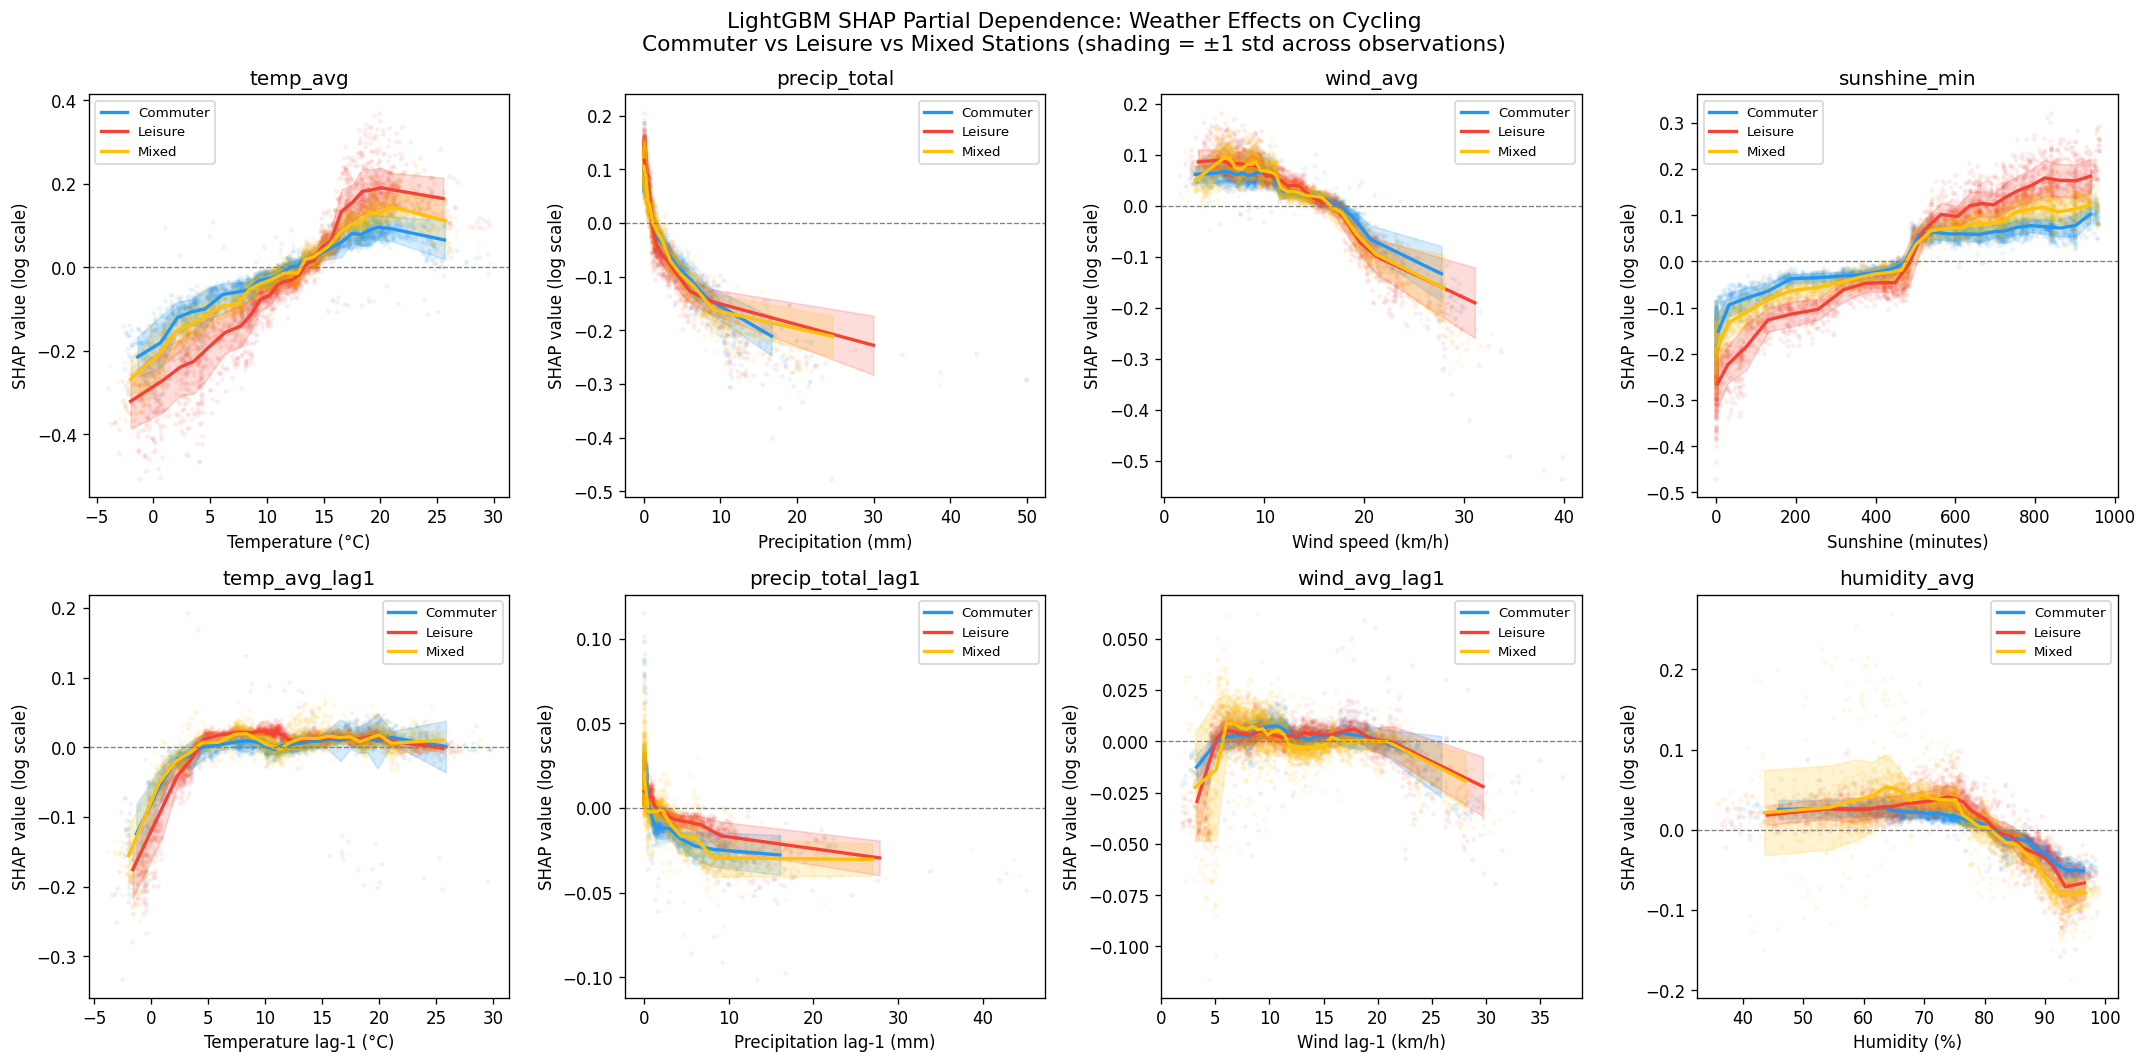

08b_lgb_shap_pdp.png saved.


In [15]:
def shap_smooth(x_vals, shap_vals, n_bins=25):
    """Bin x and return bin centres + mean ± std of SHAP values per bin."""
    bins = np.percentile(x_vals, np.linspace(0, 100, n_bins + 1))
    bins = np.unique(bins)
    centres, means, stds = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (x_vals >= lo) & (x_vals < hi)
        if mask.sum() < 3:
            continue
        centres.append((lo + hi) / 2)
        means.append(shap_vals[mask].mean())
        stds.append(shap_vals[mask].std())
    return np.array(centres), np.array(means), np.array(stds)

# 2×4 grid — same layout as notebook 08 fig20
weather_terms = [
    (0, "temp_avg",          "Temperature (°C)"),
    (1, "precip_total",      "Precipitation (mm)"),
    (2, "wind_avg",          "Wind speed (km/h)"),
    (3, "sunshine_min",      "Sunshine (minutes)"),
    (5, "temp_avg_lag1",     "Temperature lag-1 (°C)"),
    (6, "precip_total_lag1", "Precipitation lag-1 (mm)"),
    (7, "wind_avg_lag1",     "Wind lag-1 (km/h)"),
    (4, "humidity_avg",      "Humidity (%)"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, (feat_idx, feat_name, xlabel) in zip(axes, weather_terms):
    x_c = X_test_c[idx_c_s, feat_idx]
    x_l = X_test_l[idx_l_s, feat_idx]
    x_m = X_test_m[idx_m_s, feat_idx]
    s_c = shap_c[:, feat_idx]
    s_l = shap_l[:, feat_idx]
    s_m = shap_m[:, feat_idx]
    ax.scatter(x_c, s_c, alpha=0.06, s=4, color=COLORS["commuter"])
    ax.scatter(x_l, s_l, alpha=0.06, s=4, color=COLORS["leisure"])
    ax.scatter(x_m, s_m, alpha=0.06, s=4, color=COLORS["mixed"])
    for x_v, s_v, color, label in [
        (x_c, s_c, COLORS["commuter"], "Commuter"),
        (x_l, s_l, COLORS["leisure"],  "Leisure"),
        (x_m, s_m, COLORS["mixed"],  "Mixed"),
    ]:
        cx, cm, cs = shap_smooth(x_v, s_v)
        ax.plot(cx, cm, color=color, linewidth=2, label=label)
        ax.fill_between(cx, cm - cs, cm + cs, alpha=0.18, color=color)

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("SHAP value (log scale)")
    ax.set_title(feat_name)
    ax.legend(fontsize=8)

fig.suptitle(
    "LightGBM SHAP Partial Dependence: Weather Effects on Cycling\n"
    "Commuter vs Leisure vs Mixed Stations (shading = ±1 std across observations)",
    fontsize=13,
)
fig.tight_layout()
fig.savefig(FIGS / "08b_lgb_shap_pdp.png", dpi=150)
plt.show()
print("08b_lgb_shap_pdp.png saved.")


## 9. Weather-Normalized Cycling Index

Normalized cycling index saved.


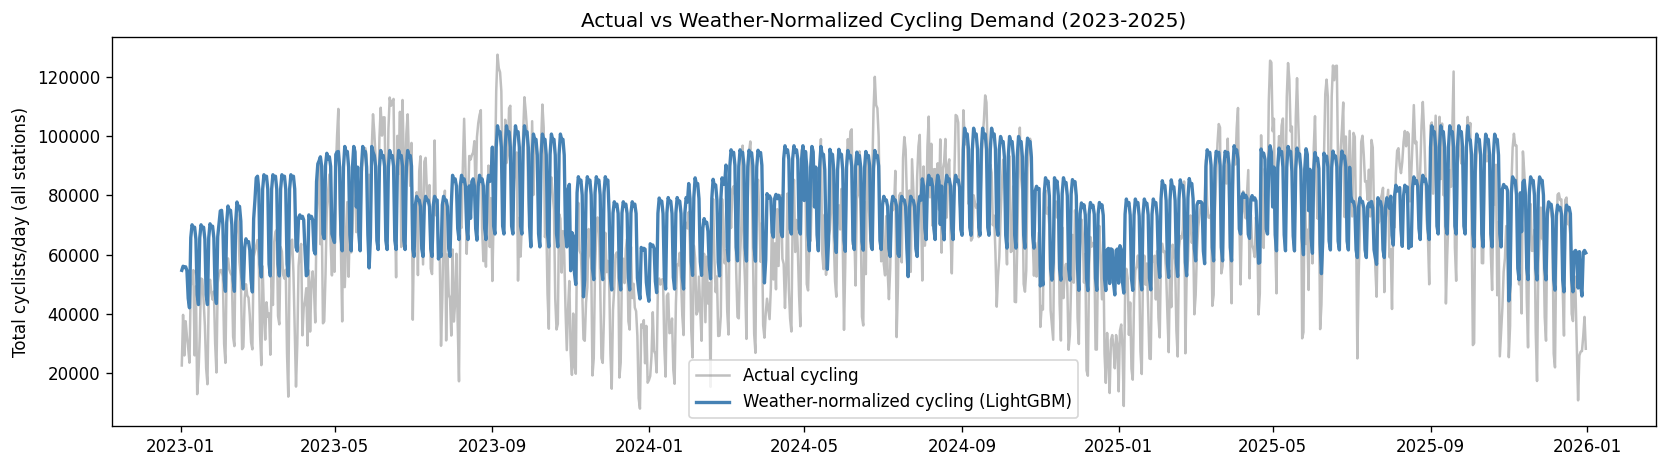

08b_normalized_vs_actual.png saved.


In [16]:
ref_weather = {
    "temp_avg"          : 15.0,
    "precip_total"      : 0.0,
    "wind_avg"          : 10.0,
    "sunshine_min"      : 300.0,
    "humidity_avg"      : 70.0,
    "temp_avg_lag1"     : 15.0,
    "precip_total_lag1" : 0.0,
    "wind_avg_lag1"     : 10.0,
}

panel_norm = panel_good.copy()
panel_norm["date"] = pd.to_datetime(panel_norm["date"])
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    panel_norm[col] = panel_norm[col].astype(int)

# Keep only rows that have all needed features
panel_norm_clean = panel_norm[ALL_FEATURES + ["site ID", "naam", "date", "aantal", "site_type", "day_type", "season"]].dropna()

# Replace weather features with reference values
X_norm = panel_norm_clean[ALL_FEATURES].values.copy().astype(np.float64)
for feat, val_ref in ref_weather.items():
    idx = ALL_FEATURES.index(feat)
    X_norm[:, idx] = val_ref

panel_norm_clean = panel_norm_clean.copy()
panel_norm_clean["normalized_count"] = lgb_full.predict(X_norm)

panel_norm_clean[["site ID", "naam", "date", "aantal",
                   "normalized_count", "site_type",
                   "day_type", "season"]].to_parquet(
    PROCESSED / "normalized_cycling.parquet", index=False
)
print("Normalized cycling index saved.")

daily_actual = panel_norm_clean.groupby("date")["aantal"].sum()
daily_norm   = panel_norm_clean.groupby("date")["normalized_count"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_actual.index, daily_actual.values, alpha=0.5, color="gray", label="Actual cycling")
ax.plot(daily_norm.index,   daily_norm.values,   color="steelblue", linewidth=2, label="Weather-normalized cycling (LightGBM)")
ax.set_title("Actual vs Weather-Normalized Cycling Demand (2023-2025)")
ax.set_ylabel("Total cyclists/day (all stations)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "08b_normalized_vs_actual.png", dpi=150)
plt.show()
print("08b_normalized_vs_actual.png saved.")


**1. Weather is the primary driver of seasonal fluctuations**

The seasonal amplitude of the actual cycling curve (grey) is far larger than the normalized curve (blue). During winter months, actual counts fall substantially below normalized levels, indicating that the winter cycling drop is largely attributable to adverse weather conditions rather than a genuine collapse in underlying demand.

**2. Calendar effects are fully preserved after normalization**

The blue curve retains a clear high-frequency oscillation throughout the entire period, reflecting the day-of-week effect (weekend peaks vs. weekday troughs).

**3. No evident growth trend in baseline cycling demand across three years**

The normalized curve holds a broadly stable mid-range level from 2023 through 2025, with no sustained upward trend.


## 10. Weather Effect Magnitudes

In [17]:
# Representative mean rows for each model's training subset
# Use raw feature values (LightGBM needs no scaling)
ref_row   = X_train.mean(axis=0)
ref_row_c = X_train_c.mean(axis=0)
ref_row_l = X_train_l.mean(axis=0)
ref_row_m = X_train_m.mean(axis=0)

def weather_effect(model, ref_row, feature_idx, bad_val, ref_val):
    """% change in predicted count when feature moves from ref_val -> bad_val."""
    X_bad = ref_row.copy()
    X_ref = ref_row.copy()
    X_bad[feature_idx] = bad_val
    X_ref[feature_idx] = ref_val
    pred_bad = model.predict(X_bad.reshape(1, -1))[0]
    pred_ref = model.predict(X_ref.reshape(1, -1))[0]
    return (pred_bad - pred_ref) / pred_ref * 100

comparisons = [
    ("Heavy rain (20mm vs 0mm)",    1, 20.0,   0.0),
    ("Light rain (2mm vs 0mm)",     1,  2.0,   0.0),
    ("Cold day (0C vs 15C)",        0,  0.0,  15.0),
    ("Cool day (8C vs 15C)",        0,  8.0,  15.0),
    ("Strong wind (40 vs 10 km/h)", 2, 40.0,  10.0),
    ("No sunshine (0 vs 300 min)",  3,  0.0, 300.0),
]

print("=" * 80)
print("LGBM WEATHER EFFECT SIZES  (% change vs reference day)")
print("=" * 80)
print(f"{'Condition':<35} | {'Full':>7} | {'Commuter':>9} | {'Leisure':>8} | {'Mixed':>7}")
print("-" * 80)
for label, feat_idx, bad_val, ref_val in comparisons:
    ef = weather_effect(lgb_full,     ref_row,   feat_idx, bad_val, ref_val)
    ec = weather_effect(lgb_commuter, ref_row_c, feat_idx, bad_val, ref_val)
    el = weather_effect(lgb_leisure,  ref_row_l, feat_idx, bad_val, ref_val)
    em = weather_effect(lgb_mixed,    ref_row_m, feat_idx, bad_val, ref_val)
    print(f"{label:<35} | {ef:>6.1f}% | {ec:>8.1f}% | {el:>7.1f}% | {em:>7.1f}%")
print("=" * 80)


LGBM WEATHER EFFECT SIZES  (% change vs reference day)
Condition                           |    Full |  Commuter |  Leisure |   Mixed
--------------------------------------------------------------------------------
Heavy rain (20mm vs 0mm)            |  -41.2% |    -34.0% |   -49.2% |   -29.2%
Light rain (2mm vs 0mm)             |  -18.9% |    -17.4% |   -30.0% |   -13.9%
Cold day (0C vs 15C)                |  -23.9% |    -24.9% |   -52.6% |   -26.4%
Cool day (8C vs 15C)                |  -13.8% |    -13.1% |   -35.1% |   -16.9%
Strong wind (40 vs 10 km/h)         |  -39.1% |    -26.2% |   -49.3% |   -29.5%
No sunshine (0 vs 300 min)          |  -11.2% |    -12.2% |   -28.6% |   -15.2%


## 11. Save Models

In [18]:
models = {
    # Keys match notebook 08 / 09 expectations
    "gam_full"      : lgb_full,
    "gam_commuter"  : lgb_commuter,
    "gam_leisure"   : lgb_leisure,
    "gam_mixed"     : lgb_mixed,
    # Encoders
    "le_site"       : le_site,
    "le_commuter"   : le_c,
    "le_leisure"    : le_l,
    "le_mixed"      : le_m,
    # Metadata
    "model_type"    : "lightgbm_poisson",
    "ALL_FEATURES"  : ALL_FEATURES,
    "ref_weather"   : ref_weather,
}
with open(PROCESSED / "gam_models.pkl", "wb") as fh:
    pickle.dump(models, fh)
print(f"Models saved to {PROCESSED / 'gam_models.pkl'}")

Models saved to /Users/zhuyuxuan/Downloads/Modern Data Analytics/mda-cycling-weather-group6/data/processed/gam_models.pkl


## 12. Final Summary

In [19]:
heavy_rain_full = weather_effect(lgb_full, ref_row, 1, 20.0,  0.0)
cold_day_full   = weather_effect(lgb_full, ref_row, 0,  0.0, 15.0)
strong_wind_full= weather_effect(lgb_full, ref_row, 2, 40.0, 10.0)

print("=" * 52)
print("LIGHTGBM MODELLING SUMMARY")
print("=" * 52)
print(f"Training period : 2023-2024 ({len(y_train):,} observations)")
print(f"Test period     : 2025     ({len(y_test):,} observations)")
print()
print("Model performance (test set):")
print(f"  Full LightGBM     : MAE={test_mae:.1f}, R²={test_r2:.3f}")
print(f"  Commuter LightGBM : MAE={mae_c:.1f}, R²={r2_c:.3f}")
print(f"  Leisure LightGBM  : MAE={mae_l:.1f}, R²={r2_l:.3f}")
print(f"  Mixed LightGBM    : MAE={mae_m:.1f}, R²={r2_m:.3f}")
print()
print("Key weather effects on cycling demand (full model):")
print(f"  Heavy rain (20mm) : {heavy_rain_full:+.1f}%")
print(f"  Cold day (0C)     : {cold_day_full:+.1f}%")
print(f"  Strong wind       : {strong_wind_full:+.1f}%")
print()
print("Outputs saved:")
print(f"  {PROCESSED / 'normalized_cycling.parquet'}")
print(f"  {PROCESSED / 'gam_models.pkl'}")
print(f"  {FIGS / '08b_lgb_shap_pdp.png'}")
print(f"  {FIGS / '08b_normalized_vs_actual.png'}")
print("=" * 52)


LIGHTGBM MODELLING SUMMARY
Training period : 2023-2024 (96,038 observations)
Test period     : 2025     (48,151 observations)

Model performance (test set):
  Full LightGBM     : MAE=115.6, R²=0.854
  Commuter LightGBM : MAE=118.2, R²=0.891
  Leisure LightGBM  : MAE=133.1, R²=0.758
  Mixed LightGBM    : MAE=91.3, R²=0.849

Key weather effects on cycling demand (full model):
  Heavy rain (20mm) : -41.2%
  Cold day (0C)     : -23.9%
  Strong wind       : -39.1%

Outputs saved:
  /Users/zhuyuxuan/Downloads/Modern Data Analytics/mda-cycling-weather-group6/data/processed/normalized_cycling.parquet
  /Users/zhuyuxuan/Downloads/Modern Data Analytics/mda-cycling-weather-group6/data/processed/gam_models.pkl
  /Users/zhuyuxuan/Downloads/Modern Data Analytics/mda-cycling-weather-group6/outputs/figures/08b_lgb_shap_pdp.png
  /Users/zhuyuxuan/Downloads/Modern Data Analytics/mda-cycling-weather-group6/outputs/figures/08b_normalized_vs_actual.png
